# Kmeans clustering

# Import libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Import - Preprocess the dataset

In [40]:
def load_and_scale_dataset(path, header=None):
    # load dataset
    dataset = pd.read_csv(path, header=header, on_bad_lines='skip')

    # convert to numeric όπου γίνεται, αλλιώς NaN
    dataset = dataset.apply(pd.to_numeric, errors='coerce')

    # drop NaN rows
    dataset = dataset.dropna()
    X = dataset.to_numpy()
    # scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler, dataset




In [41]:
def find_global_knn_outliers(X, k=7, pct=99.9):

    n = X.shape[0]

    # 1) φτιάχνουμε NearestNeighbors για ΟΛΟ το dataset
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)

    # 2) distances προς τους k+1 κοντινότερους (1ος = εαυτός)
    dists, indices = nbrs.kneighbors(X)
    # dists.shape = (n, k+1)

    # 3) μέσος όρος αποστάσεων προς τους k κοντινούς (χωρίς τον εαυτό)
    mean_dist = dists[:, 1:].mean(axis=1)   # shape: (n,)

    # 4) threshold: pct% των σημείων έχουν mean_dist <= thr
    thr = np.percentile(mean_dist, pct)

    # 5) outliers = όσα έχουν mean_dist > thr
    outlier_mask = mean_dist > thr

    return outlier_mask, mean_dist, thr


In [42]:
X, scaler, dataset = load_and_scale_dataset('synthetic_2d_xy_only.csv', header=None)

In [43]:
outlier_mask, mean_dist, thr = find_global_knn_outliers(
    X,
    k=4,
    pct=95.0
)

print("Total points:", X.shape[0])
print("Outliers found:", outlier_mask.sum())

X_clean = X[~outlier_mask]
dataset_clean = dataset[~outlier_mask]


Total points: 70080
Outliers found: 3504


# Use elbow methot - silhouette to find optimal number of clusters


In [44]:
def find_best_k_silhouette(X, k_min=1, k_max=10, sample_size=10000, plot_elbow=True):

    wcss = []
    sil_scores = []
    ks_for_sil = []

    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(X)

        # Elbow metric
        wcss.append(kmeans.inertia_)

        # Silhouette only for k >= 2
        if k >= 2:
            sil = silhouette_score(
                X,
                kmeans.labels_,
                sample_size=min(sample_size, X.shape[0]),
                random_state=42
            )
            sil_scores.append(sil)
            ks_for_sil.append(k)

    # find best siluette
    if sil_scores:
        best_k_sil = ks_for_sil[int(np.argmax(sil_scores))]
    else:
        best_k_sil = None

    print('Best k with silhouette is:', best_k_sil)

    # Elbow plot
    if plot_elbow:
        plt.plot(range(k_min, k_max + 1), wcss)
        plt.title('Elbow Method')
        plt.xlabel('Number of clusters')
        plt.ylabel('WCSS')
        plt.show()

    return best_k_sil, wcss, sil_scores, ks_for_sil

Best k with silhouette is: 3


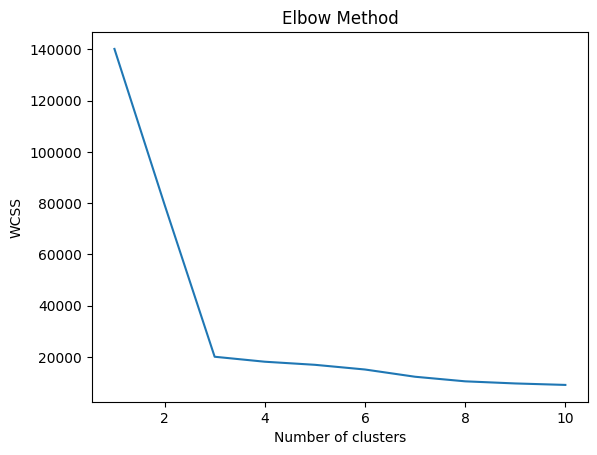

In [45]:
best_k_sil, wcss, sil_scores, ks_for_sil = find_best_k_silhouette(
    X,
    k_min=1,
    k_max=10,
    sample_size=10000,
    plot_elbow=True
)


# Train K-Means model on the dataset

In [46]:

def run_kmeans(X, n_clusters, random_state=42):

    kmeans = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        random_state=random_state
    )
    y_kmeans = kmeans.fit_predict(X)
    return kmeans, y_kmeans

In [47]:
kmeans, y_kmeans = run_kmeans(X, best_k_sil, random_state=42)
print(y_kmeans[:50])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2]


# Detect outliers

In [48]:

def find_cluster_knn_outliers(X, labels, k=7, pct=99.99):

    n = X.shape[0]
    outlier_mask = np.zeros(n, dtype=bool)

    for c in np.unique(labels):              # for each cluster
        idx = np.where(labels == c)[0]
        X_c = X[idx]

        # if cluster is too small, bypass
        if len(X_c) <= k:
            continue

        n_neighbors = min(k + 1, len(X_c))
        nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_c)
        dists, indices = nbrs.kneighbors(X_c)
        # dists.shape = (cluster_points, n_neighbors)

        # find mean of ngb without it self (χωρίς τον εαυτό)
        mean_dist = dists[:, 1:].mean(axis=1)   # shape: (m,)

        # threshold for pct of points to have mean_dist <= thr
        thr = np.percentile(mean_dist, pct)

        # mean_dist > thr points are too sparse -> outliers
        cluster_outliers = mean_dist > thr      # shape: (m,)

        # write outliers to total mask
        outlier_mask[idx] = cluster_outliers

    # return mask
    outliers = X[outlier_mask]
    return outlier_mask, outliers

In [49]:
outlier_mask, outliers = find_cluster_knn_outliers(
    X,
    y_kmeans,
    k=7,
    pct=99.99
)

# Visualise the clusters

In [50]:
def plot_clusters_with_outliers(X, labels, kmeans, outliers, title='Clusters of data'):
    unique_clusters = np.unique(labels)

    plt.figure()

    # scatter each cluster
    for c in unique_clusters:
        plt.scatter(
            X[labels == c, 0],
            X[labels == c, 1],
            s=8,
            label=f'Cluster {c}'
        )

    # Centroids
    plt.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        s=40,
        c='black',
        label='Centroids'
    )

    # Outliers
    if outliers is not None and len(outliers) > 0:
        plt.scatter(
            outliers[:, 0],
            outliers[:, 1],
            c='red',
            marker='x',
            s=80,
            label='Outliers'
        )

    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.show()



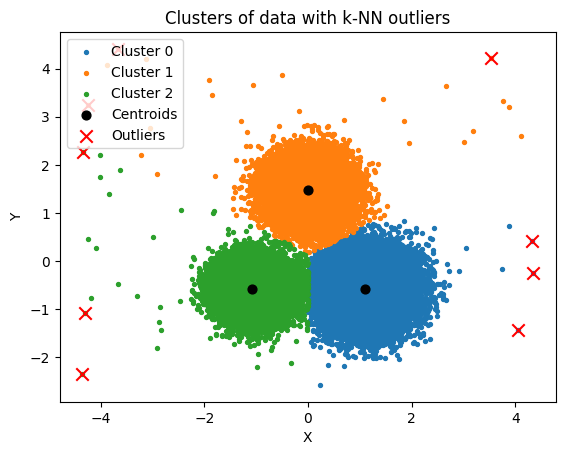

In [51]:
plot_clusters_with_outliers(X, y_kmeans, kmeans, outliers, title='Clusters of data with k-NN outliers')